# LMS

In [6]:
import numpy as np

# =========================
# DATOS (AND lógico)
# =========================
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])
print("Datos de entrada (X):")
print(X)
print("\nEtiquetas (y):")
print(y)
# =========================
# INICIALIZACIÓN
# =========================
np.random.seed(0)

# Pesos w ~ N(0,1)
w = np.random.randn(2)

# Bias b ~ N(0,1)
b = np.random.randn()

# =========================
# FUNCIÓN DE ACTIVACIÓN
# =========================
def sigmoid(z):
    """
    Función sigmoide:
    
    σ(z) = 1 / (1 + e^{-z})
    
    Convierte valores reales a rango (0,1),
    interpretables como probabilidades.
    """
    return 1 / (1 + np.exp(-z))

# =========================
# ENTRENAMIENTO
# =========================
lr = 0.1       # tasa de aprendizaje (η)
epochs = 1000  # número de iteraciones

for _ in range(epochs):
    
    # =========================
    # FORWARD (propagación)
    # =========================
    
    """
    Modelo lineal:
    
    z = X·w + b
    
    donde:
    - X: matriz de entradas (N x d)
    - w: vector de pesos (d)
    - b: sesgo
    """
    z = np.dot(X, w) + b
    
    """
    Activación:
    
    y_pred = σ(z)
    
    salida probabilística
    """
    y_pred = sigmoid(z)
    
    # =========================
    # ERROR
    # =========================
    
    """
    Error (para pérdida tipo log-loss simplificada):
    
    error = y_pred - y
    
    Esto proviene del gradiente de la función de
    pérdida logística (cross-entropy).
    """
    error = y_pred - y
    
    # =========================
    # GRADIENTES
    # =========================
    
    """
    Gradiente respecto a los pesos:
    
    ∂L/∂w = (1/N) * Xᵀ (y_pred - y)
    """
    dw = np.dot(X.T, error) / len(X)
    
    """
    Gradiente respecto al bias:
    
    ∂L/∂b = (1/N) * Σ (y_pred - y)
    """
    db = np.mean(error)
    
    # =========================
    # ACTUALIZACIÓN (Gradient Descent)
    # =========================
    
    """
    Regla de actualización:
    
    w = w - η * ∂L/∂w
    b = b - η * ∂L/∂b
    
    donde η es la tasa de aprendizaje
    """
    w -= lr * dw
    b -= lr * db

# =========================
# RESULTADOS
# =========================
print("Pesos:", w)
print("Bias:", b)

print("\nPredicciones:")

"""
Predicción final:

ŷ = σ(X·w + b)
"""
print(sigmoid(np.dot(X, w) + b))

Datos de entrada (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Etiquetas (y):
[0 0 0 1]
Pesos: [3.10719623 3.0875146 ]
Bias: -4.861458297848935

Predicciones:
[0.00767975 0.14505258 0.14751043 0.79137813]


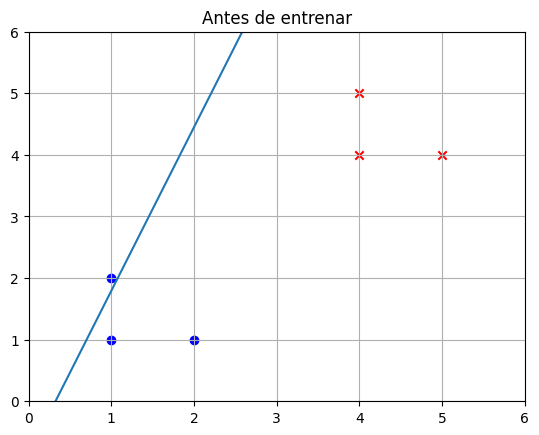

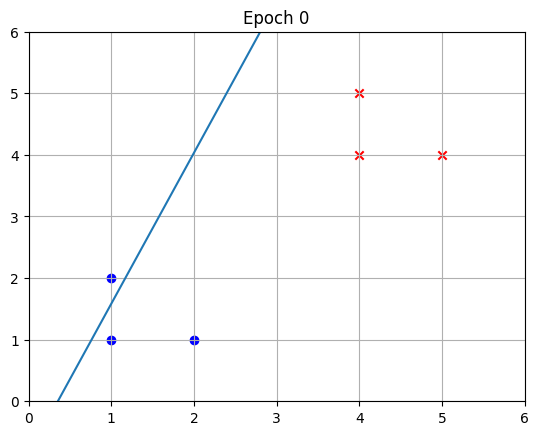

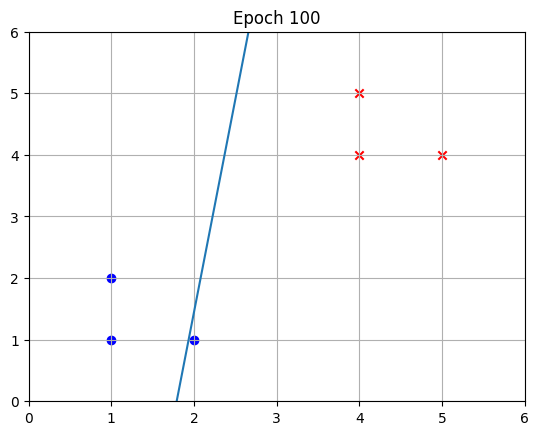

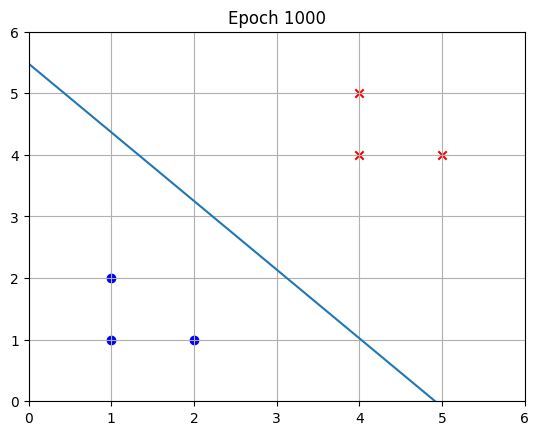

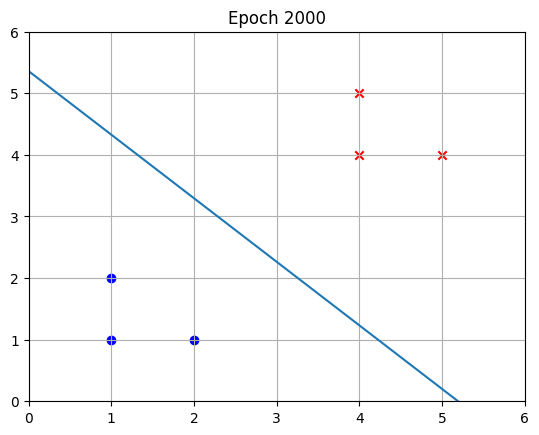

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Datos simples (clasificación)
X = np.array([
    [1, 1],
    [2, 1],
    [1, 2],
    [4, 4],
    [5, 4],
    [4, 5]
])

y = np.array([0, 0, 0, 1, 1, 1])

# Inicialización
np.random.seed(1)
w = np.random.randn(2)
b = np.random.randn()

lr = 0.1
epochs = 2001

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Función para graficar
def plot_boundary(X, y, w, b, title):
    plt.figure()
    
        # puntos
    for i in range(len(X)):
        if y[i] == 0:
            plt.scatter(X[i,0], X[i,1], marker='o',color='blue')
        else:
            plt.scatter(X[i,0], X[i,1], marker='x',color='red')
        
    # línea de decisión: w1*x1 + w2*x2 + b = 0
    x_vals = np.linspace(0, 6, 100)
    y_vals = -(w[0]*x_vals + b) / w[1]
    
    plt.plot(x_vals, y_vals)
    plt.xlim(0,6)
    plt.ylim(0,6)
    plt.title(title)
    plt.grid()
    plt.show()

# Antes de entrenar
plot_boundary(X, y, w, b, "Antes de entrenar")

# Entrenamiento
for epoch in range(epochs):
    
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    
    error = y_pred - y
    
    dw = np.dot(X.T, error) / len(X)
    db = np.mean(error)
    
    w -= lr * dw
    b -= lr * db
    
    if epoch in [0,100,1000,2000]:
        plot_boundary(X, y, w, b, f"Epoch {epoch}")

# PERCEPTRON DE BOLSILLO 

In [4]:
import numpy as np

class PerceptronBolsillo:
    def __init__(self, eta=1.0, max_iter=1000):
        self.eta = eta                  # Tasa de aprendizaje
        self.max_iter = max_iter        # Criterio de parada
        self.w = None                   # Pesos actuales
        self.w_bolsillo = None          # Mejores pesos encontrados
        self.t = 0                      # Aciertos consecutivos actuales
        self.t_max = 0                  # Récord de aciertos

    def _agregar_bias(self, X):
        """
        Vectores extendidos: añade 1 para incorporar el bias en w
        """
        N = X.shape[0]
        return np.hstack((np.ones((N, 1)), X))

    def _funcion_activacion(self, z):
        """
        f_LD: función signo
        """
        return np.where(z >= 0, 1, -1)

    def fit(self, X, y):
        """
        Entrenamiento usando el algoritmo de bolsillo
        """
        # Asegurar etiquetas en {-1, 1}
        y = np.where(y == 0, -1, y)

        # Vectores extendidos
        X_ext = self._agregar_bias(X)

        # Inicialización
        d = X_ext.shape[1]
        self.w = np.zeros(d)
        self.w_bolsillo = np.zeros(d)
        self.t = 0
        self.t_max = 0

        # Bucle principal
        for _ in range(self.max_iter):

            # Selección aleatoria de muestra
            i = np.random.randint(0, X_ext.shape[0])
            xi = X_ext[i]
            yi = y[i]

            # Evaluación
            condicion = np.dot(self.w, xi) * yi

            if condicion > 0:
                # Clasificación correcta
                self.t += 1

                if self.t > self.t_max:
                    self.t_max = self.t
                    self.w_bolsillo = self.w.copy()

            else:
                # Clasificación incorrecta → actualización
                self.w = self.w + self.eta * xi * yi
                self.t = 0

        return self.w_bolsillo

    def predict(self, X):
        """
        Predicción usando los pesos del bolsillo
        """
        X_ext = self._agregar_bias(X)
        z = np.dot(X_ext, self.w_bolsillo)
        return self._funcion_activacion(z)


# =========================
# EJEMPLO DE USO
# =========================

if __name__ == "__main__":
    
    # Datos NO linealmente separables
    X = np.array([
        [1, 1],
        [2, 1],
        [1, 2],
        [2, 2],
        [3, 3],
        [3, 1]
    ])

    y = np.array([1, 1, -1, -1, 1, -1])

    modelo = PerceptronBolsillo(eta=0.4, max_iter=100000)
    
    w_best = modelo.fit(X, y)

    print("Pesos del bolsillo:")
    print(w_best)

    predicciones = modelo.predict(X)
    print("\nPredicciones:")
    print(predicciones)

    print("\nEtiquetas reales:")
    print(y)

Pesos del bolsillo:
[ 0.4 -0.4  0.4]

Predicciones:
[ 1  1  1  1  1 -1]

Etiquetas reales:
[ 1  1 -1 -1  1 -1]
